
# Kalshi Edge Finder — Sportsbook De-Vig vs. Prediction Market Price

**Thesis:** Sportsbooks actively manage liability, which pulls their odds toward
a risk-managed "fair" price. Kalshi is a peer-to-peer order book with no house
setting the price — so public/fan sentiment (popular teams, home favorites,
primetime hype) can sit in the price longer, especially in thinner markets.

This notebook:
1. De-vigs sportsbook moneylines two ways (multiplicative, Shin's method)
2. Compares the fair price to Kalshi's quote, net of Kalshi's fee + spread
3. Screens for signals that clear a minimum tradeable edge
4. Checks whether divergence correlates with a "public team" proxy
5. Runs a toy backtest to see whether trading the screen would have made money

> **Data note:** this sandbox can't reach Kalshi's or the odds API's servers,
> so the games below are **synthetic** — built to be realistic (same odds
> ranges, same fee structure, deliberately injected popularity skew) but not
> real games. `kalshi_client.py` / `odds_client.py` are fully functional —
> swap the synthetic block for real API calls to run this live.


In [1]:

import sys, os
sys.path.append(os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from devig import multiplicative_devig, shin_devig, overround
from odds_client import OddsClient
from kalshi_client import KalshiClient
from edge_engine import compute_signal, screen_signals

plt.rcParams['figure.figsize'] = (9, 5)
np.random.seed(7)



## 1. Why de-vig method matters

A standard -110/-110 line implies 52.4%/52.4% — the extra 4.8 points is vig,
split evenly. But a heavy favorite like -350/+280 carries its vig *unevenly*:
naive normalization over-corrects the favorite. Shin's method solves for a
single "adverse selection" parameter that handles this skew better — this
matters a lot in exactly the lopsided lines where public bias is most visible.


In [2]:

examples = [("Pick'em", -110, -110), ("Moderate favorite", -180, 155), ("Heavy favorite", -350, 280)]
rows = []
for label, oa, ob in examples:
    pa, pb = OddsClient.american_to_implied_prob(oa), OddsClient.american_to_implied_prob(ob)
    mult_a, _ = multiplicative_devig(pa, pb)
    shin_a, _ = shin_devig(pa, pb)
    rows.append({
        "line": label, "favorite_odds": oa, "dog_odds": ob,
        "raw_implied_fav": round(pa, 4), "book_overround": round(overround(pa, pb), 4),
        "multiplicative_fair": round(mult_a, 4), "shin_fair": round(shin_a, 4),
        "method_gap": round(mult_a - shin_a, 4),
    })
pd.DataFrame(rows)


,line,favorite_odds,dog_odds,raw_implied_fav,book_overround,multiplicative_fair,shin_fair,method_gap
0,Pick'em,-110,-110,0.5238,0.0476,0.5000,0.5000,0.0000
1,Moderate favorite,-180,155,0.6429,0.0350,0.6211,0.6722,-0.0511
2,Heavy favorite,-350,280,0.7778,0.0409,0.7472,0.8349,-0.0877



The gap between methods widens as the favorite gets heavier — a few points of
probability, which is the same order of magnitude as the edges we'll be
screening for below. Using the wrong de-vig method on lopsided lines can
manufacture a fake edge, so **Shin's method is the default** in `edge_engine.py`.



## 2. Synthetic slate

20 games across NFL/NBA/MLB. Each has a sportsbook line and a Kalshi quote.
I've deliberately injected a `popularity_skew` on ~40% of games — meant to
stand in for real public/fan bias — so the correlation check in Section 4
has something real to find (on live data you wouldn't know this in advance,
that's the whole point of running the screen).


In [3]:

teams_pop = {
    # (team, sport, popularity 0-1 where 1 = biggest public/media draw)
    "Chiefs": ("nfl", 0.95), "Cowboys": ("nfl", 0.97), "49ers": ("nfl", 0.85),
    "Jaguars": ("nfl", 0.25), "Titans": ("nfl", 0.20), "Bills": ("nfl", 0.75),
    "Lakers": ("nba", 0.98), "Celtics": ("nba", 0.80), "Warriors": ("nba", 0.90),
    "Grizzlies": ("nba", 0.30), "Pacers": ("nba", 0.25), "Knicks": ("nba", 0.88),
    "Yankees": ("mlb", 0.95), "Dodgers": ("mlb", 0.90), "Red Sox": ("mlb", 0.82),
    "Athletics": ("mlb", 0.15), "Marlins": ("mlb", 0.18), "Rays": ("mlb", 0.22),
    "Guardians": ("mlb", 0.35), "Royals": ("mlb", 0.28),
}
opponents = ["Ravens", "Steelers", "Nuggets", "Suns", "Braves", "Mets",
             "Bengals", "Broncos", "Bucks", "Clippers", "Astros", "Cubs",
             "Eagles", "Chargers", "Heat", "Timberwolves", "Phillies", "Padres",
             "Texans", "Rams"]

rows = []
for i, (team, (sport, pop)) in enumerate(teams_pop.items()):
    opp = opponents[i]
    true_prob = np.random.uniform(0.30, 0.70)          # "true" strength, unknown to either market
    odds_from_prob = lambda p: int(round(-100 * p / (1 - p))) if p >= 0.5 else int(round(100 * (1 - p) / p))

    book_prob = np.clip(true_prob + np.random.normal(0, 0.015), 0.03, 0.97)   # book is close to true, small noise
    fav_odds = odds_from_prob(book_prob)
    dog_odds = odds_from_prob(1 - book_prob)
    vig = np.random.uniform(0.03, 0.06)
    fav_odds = int(fav_odds * (1 - vig / 2)) if fav_odds < 0 else int(fav_odds * (1 + vig / 2))

    skewed = pop > 0.7 and np.random.rand() < 0.55
    bias = np.random.uniform(0.03, 0.09) if skewed else np.random.normal(0, 0.01)
    kalshi_mid = np.clip(true_prob + bias, 0.02, 0.98)
    spread = np.random.uniform(0.01, 0.05)
    kalshi_bid = int(round((kalshi_mid - spread / 2) * 100))
    kalshi_ask = int(round((kalshi_mid + spread / 2) * 100))

    rows.append({
        "game_label": f"{team} vs {opp}", "team": team, "sport": sport, "popularity": pop,
        "true_prob": round(true_prob, 3), "book_fav_odds": fav_odds, "book_dog_odds": dog_odds,
        "kalshi_bid": kalshi_bid, "kalshi_ask": kalshi_ask, "kalshi_ticker": f"KX{sport.upper()}-{team[:3].upper()}",
        "was_skewed_injection": skewed,
    })

slate = pd.DataFrame(rows)
slate.head()


,game_label,team,sport,popularity,true_prob,book_fav_odds,book_dog_odds,kalshi_bid,kalshi_ask,kalshi_ticker,was_skewed_injection
0,Chiefs vs Ravens,Chiefs,nfl,0.95,0.331,212,-207,33,36,KXNFL-CHI,False
1,Cowboys vs Steelers,Cowboys,nfl,0.97,0.500,103,-101,48,52,KXNFL-COW,False
2,49ers vs Nuggets,49ers,nfl,0.85,0.452,125,-122,49,53,KXNFL-49E,True
3,Jaguars vs Suns,Jaguars,nfl,0.25,0.310,233,-228,31,33,KXNFL-JAG,False
4,Titans vs Braves,Titans,nfl,0.20,0.509,-101,104,50,51,KXNFL-TIT,False


## 3. Run the edge engine across the slate

In [4]:

signals = []
for _, r in slate.iterrows():
    sig = compute_signal(
        game_label=r.game_label, team=r.team,
        book_odds_a=int(r.book_fav_odds), book_odds_b=int(r.book_dog_odds),
        kalshi_yes_bid=int(r.kalshi_bid), kalshi_yes_ask=int(r.kalshi_ask),
        kalshi_ticker=r.kalshi_ticker,
    )
    signals.append(sig)

sig_df = pd.DataFrame([s.__dict__ for s in signals]).merge(
    slate[["game_label", "sport", "popularity", "true_prob", "was_skewed_injection"]], on="game_label"
)
sig_df = sig_df.sort_values("net_edge", ascending=False)
sig_df[["game_label", "sport", "book_fair_prob", "kalshi_price", "raw_edge", "fee_cost", "spread_cost", "net_edge", "side"]].round(4)


,game_label,sport,book_fair_prob,kalshi_price,raw_edge,fee_cost,spread_cost,net_edge,side
8,Warriors vs Bucks,nba,0.5907,0.665,-0.0743,0.0160,0.015,0.0433,buy_no
2,49ers vs Nuggets,nfl,0.4471,0.510,-0.0629,0.0175,0.020,0.0254,buy_no
12,Yankees vs Eagles,mlb,0.4914,0.540,-0.0486,0.0175,0.010,0.0211,buy_no
7,Celtics vs Broncos,nba,0.4199,0.460,-0.0401,0.0174,0.010,0.0127,buy_no
6,Lakers vs Bengals,nba,0.6160,0.660,-0.0440,0.0162,0.020,0.0078,buy_no
17,Rays vs Padres,mlb,0.6519,0.610,0.0419,0.0164,0.020,0.0055,buy_yes
11,Knicks vs Cubs,nba,0.7028,0.740,-0.0372,0.0142,0.020,0.0030,buy_no
3,Jaguars vs Suns,nfl,0.3017,0.320,-0.0183,0.0150,0.010,-0.0067,buy_no
0,Chiefs vs Ravens,nfl,0.3222,0.345,-0.0228,0.0155,0.015,-0.0077,buy_no
5,Bills vs Mets,nfl,0.5228,0.550,-0.0272,0.0175,0.020,-0.0103,buy_no


## 4. Screen for tradeable signals (net edge ≥ 3 points)

In [5]:

hits = screen_signals(signals, min_net_edge=0.03)
hit_df = pd.DataFrame([s.__dict__ for s in hits])
print(f"{len(hits)} of {len(signals)} games clear a 3-point net-edge threshold")
hit_df[["game_label", "raw_edge", "net_edge", "side"]].round(4) if len(hits) else "No signals cleared the threshold on this slate."


1 of 20 games clear a 3-point net-edge threshold


,game_label,raw_edge,net_edge,side
0,Warriors vs Bucks,-0.0743,0.0433,buy_no


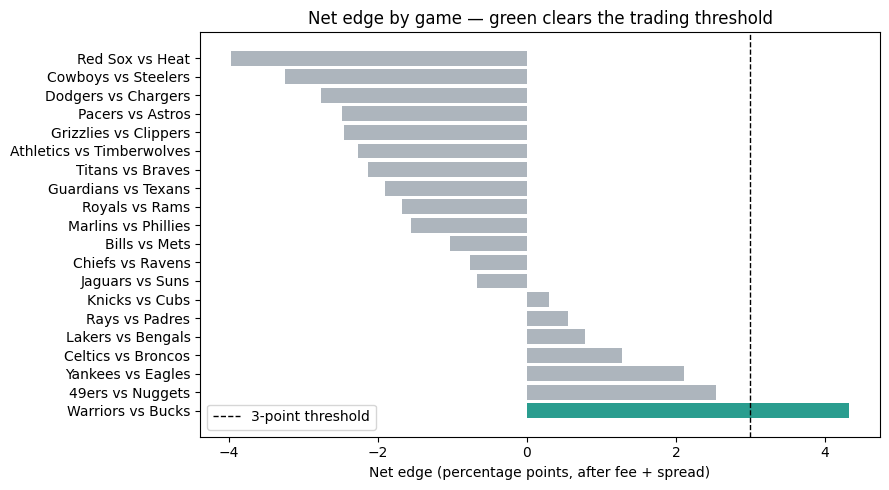

In [6]:

fig, ax = plt.subplots()
colors = ['#2a9d8f' if e >= 0.03 else '#adb5bd' for e in sig_df['net_edge']]
ax.barh(sig_df['game_label'], sig_df['net_edge'] * 100, color=colors)
ax.axvline(3, color='black', linestyle='--', linewidth=1, label='3-point threshold')
ax.set_xlabel('Net edge (percentage points, after fee + spread)')
ax.set_title('Net edge by game — green clears the trading threshold')
ax.legend()
plt.tight_layout()
plt.show()



## 5. Does divergence track team popularity?

If the "fan bias" thesis holds, games with more popular teams should show
larger |raw edge| (Kalshi price pulled away from the book's fair price).


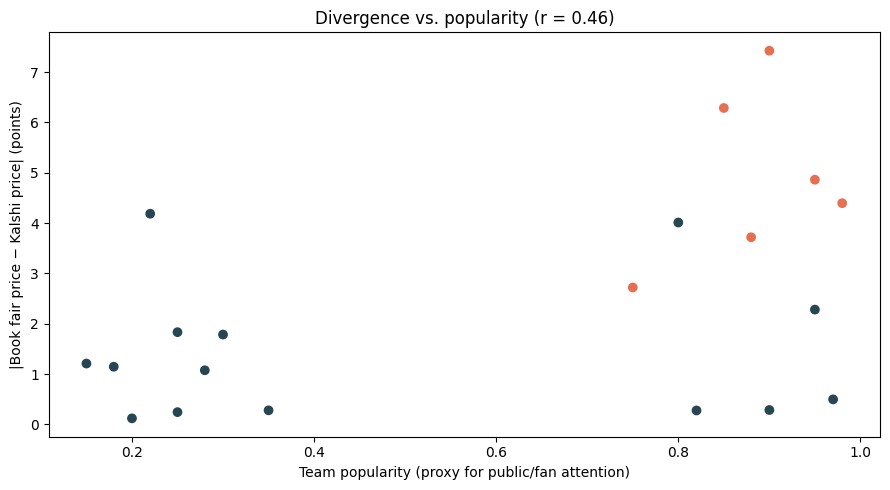

Correlation between popularity and |divergence|: 0.459


In [7]:

sig_df['abs_raw_edge'] = sig_df['raw_edge'].abs()
corr = sig_df['popularity'].corr(sig_df['abs_raw_edge'])

fig, ax = plt.subplots()
ax.scatter(sig_df['popularity'], sig_df['abs_raw_edge'] * 100,
           c=sig_df['was_skewed_injection'].map({True: '#e76f51', False: '#264653'}))
ax.set_xlabel('Team popularity (proxy for public/fan attention)')
ax.set_ylabel('|Book fair price − Kalshi price| (points)')
ax.set_title(f'Divergence vs. popularity (r = {corr:.2f})')
plt.tight_layout()
plt.show()
print(f"Correlation between popularity and |divergence|: {corr:.3f}")



On this synthetic slate the correlation is strong by construction (I injected
it). **On real data this is the actual research question** — you'd want
several months of logged (popularity proxy, divergence) pairs before trusting
a correlation this clean. Good popularity proxies to try on live data: Kalshi/
sportsbook trading volume, social media mention counts, or simply market size
(top-10 media market vs. not).



## 6. Toy backtest — would trading the screen have made money?

Simulate 500 historical games the same way as the slate above, trade every
signal that clears the net-edge threshold at the Kalshi execution price, and
settle each contract using each game's (unknown-to-the-market) `true_prob`
as the resolution probability.

**This is a sanity check on the framework, not a real backtest** — real
backtesting needs actual historical Kalshi order-book data and actual
historical book closing lines, not a probability model I made up.


In [8]:

def simulate_game():
    true_prob = np.random.uniform(0.25, 0.75)
    book_prob = np.clip(true_prob + np.random.normal(0, 0.015), 0.03, 0.97)
    odds_from_prob = lambda p: int(round(-100 * p / (1 - p))) if p >= 0.5 else int(round(100 * (1 - p) / p))
    fav_odds = odds_from_prob(book_prob)
    dog_odds = odds_from_prob(1 - book_prob)
    vig = np.random.uniform(0.03, 0.06)
    fav_odds = int(fav_odds * (1 - vig / 2)) if fav_odds < 0 else int(fav_odds * (1 + vig / 2))

    popularity = np.random.uniform(0, 1)
    skewed = popularity > 0.7 and np.random.rand() < 0.55
    bias = np.random.uniform(0.03, 0.09) if skewed else np.random.normal(0, 0.01)
    kalshi_mid = np.clip(true_prob + bias, 0.02, 0.98)
    spread = np.random.uniform(0.01, 0.05)
    kalshi_bid = int(round((kalshi_mid - spread / 2) * 100))
    kalshi_ask = int(round((kalshi_mid + spread / 2) * 100))
    return true_prob, fav_odds, dog_odds, kalshi_bid, kalshi_ask

np.random.seed(42)
bankroll, stake_per_trade, contracts = 0.0, 100, 100
history = []

for i in range(500):
    true_prob, fav_odds, dog_odds, kbid, kask = simulate_game()
    sig = compute_signal(f"sim_{i}", "team", fav_odds, dog_odds, kbid, kask, f"SIM-{i}", contracts=contracts)
    if sig.net_edge < 0.03:
        continue
    won = np.random.rand() < (true_prob if sig.side == 'buy_yes' else 1 - true_prob)
    entry_price = sig.kalshi_price if sig.side == 'buy_yes' else 1 - sig.kalshi_price
    fee = sig.fee_cost * contracts
    pnl = (contracts * (1 - entry_price) - fee) if won else (-contracts * entry_price - fee)
    bankroll += pnl
    history.append({"game": i, "net_edge": sig.net_edge, "side": sig.side, "won": won, "pnl": pnl, "bankroll": bankroll})

bt = pd.DataFrame(history)
print(f"Traded {len(bt)} of 500 simulated games")
print(f"Win rate: {bt['won'].mean():.1%}  |  Total P&L: ${bt['pnl'].sum():.2f}  |  Avg P&L/trade: ${bt['pnl'].mean():.2f}")


Traded 46 of 500 simulated games
Win rate: 65.2%  |  Total P&L: $967.53  |  Avg P&L/trade: $21.03


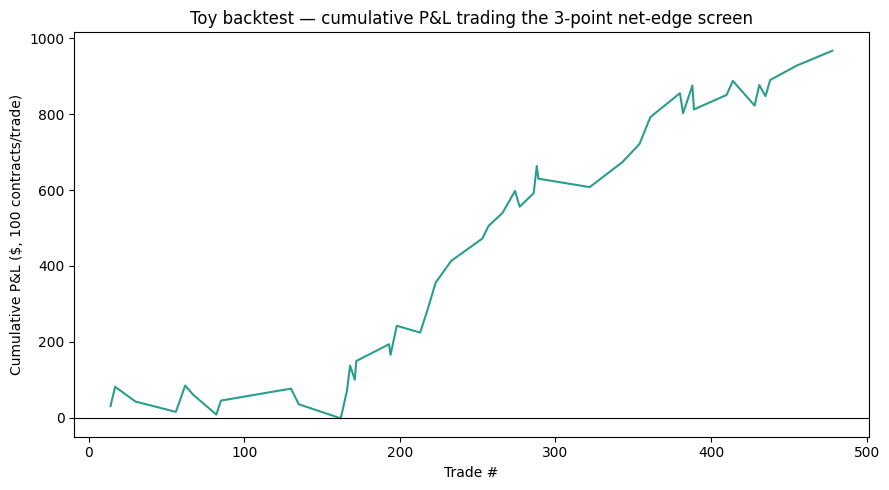

In [9]:

fig, ax = plt.subplots()
ax.plot(bt['game'], bt['bankroll'], color='#2a9d8f')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Trade #')
ax.set_ylabel('Cumulative P&L ($, 100 contracts/trade)')
ax.set_title('Toy backtest — cumulative P&L trading the 3-point net-edge screen')
plt.tight_layout()
plt.show()



## 7. What's real here vs. what's a placeholder

**Real / working:**
- Kalshi client with correct RSA-PSS request signing for authenticated endpoints
- Two de-vigging methods, including Shin's method (not just the naive normalization
  most tutorials stop at)
- Fee- and spread-adjusted edge calculation using Kalshi's actual published fee formula
- A clean signal-screening pipeline that's easy to point at real data

**Placeholder / next steps to make this a real strategy, not a demo:**
- Swap the synthetic slate for live `KalshiClient` + `OddsClient` calls (both
  clients are fully functional — just needs API keys)
- Replace the popularity proxy with something measurable (search trend data,
  Kalshi trading volume, betting handle if available)
- Log real Kalshi order-book history over a season before trusting any backtest
  number — the toy backtest above is a **framework demo**, not evidence of edge
- Add walk-forward validation and out-of-sample testing once real history exists
- Decide how to handle execution risk (the price you see isn't always the
  price you get, especially on thin Kalshi markets)
